# Image Recognition Project — Model 2: EfficientNet-B0 as Feature Extractor

EfficientNet-B0 is a lightweight convolutional neural network pre-trained on 1.2 million ImageNet images.
We freeze most of its layers and only train a custom classifier head on top of the extracted features.

**Difference from Model 1:**
- **Model 1:** The entire network was trained from scratch on our small dataset → severe overfitting
- **Model 2:** EfficientNet-B0 acts as a frozen feature extractor → only the classifier head is learned


## 1. Imports

In [1]:
import torch
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report
import itertools
from torch.utils.data import ConcatDataset, Subset
import torch.nn as nn

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available:  {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.11.0+cu128
CUDA available:  True
GPU: NVIDIA GeForce RTX 5080


## 2. Why Pure PyTorch?

Model 1 used the Keras API with a PyTorch backend, which caused several issues
(kernel crashes, Permute layer incompatibilities, etc.).

From Model 2 onwards we use **torchvision pretrained models directly**,
which is more natural with PyTorch and avoids those problems.
The training loop is written by hand — it's more verbose but fully transparent and debuggable.

## 3. Configuration




In [2]:
torch.set_float32_matmul_precision('high')

IMG_SIZE             = 299
BATCH_SIZE           = 32
EPOCHS               = 30
LR                   = 1e-3
WEIGHT_DECAY         = 1e-4
NUM_WORKERS          = 10
EARLY_STOP_PATIENCE  = 10

model_dir = "models/feature_extraction"

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

Using device: cuda


## 4. Data Transforms & Loading

### Why ImageNet normalization?
Pre-trained models like EfficientNet-B0 were trained with inputs normalized to
ImageNet statistics. Using different normalization would shift the feature distributions
the frozen layers expect, degrading performance.

### Training augmentations
The training transform applies several random augmentations to artificially expand the dataset
and improve generalization:

| Augmentation | Purpose |
|---|---|
| `RandomHorizontalFlip` | Plushies look the same mirrored |
| `RandomVerticalFlip` | Adds orientation variety |
| `RandomRotation(20)` | Handles tilted photos |
| `ColorJitter` | Simulates different lighting and camera settings |
| `RandomGrayscale` | Reduces color dependence |
| `RandomPerspective` | Simulates different camera angles |
| `RandomAffine` | Simulates slight translations |

### Validation/test transform
No augmentation — only resize and normalize. We want to evaluate on clean, unmodified images.

In [3]:
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2, hue=0.1),
    transforms.RandomGrayscale(p=0.1),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

test_dataset = datasets.ImageFolder("./data/test", transform=val_test_transform)

CLASS_NAMES = datasets.ImageFolder("./data/train").classes
NUM_CLASSES = len(CLASS_NAMES)
print(f"Found {NUM_CLASSES} classes: {CLASS_NAMES}")
print(f"Test: {len(test_dataset)}")

Found 2 classes: ['chocopuni', 'fumo']
Test: 40


## 5. Cross-Validation Data Pool

Instead of a fixed train/val split, we merge both the `train` and `validation` folders
into one large pool and let **Stratified K-Fold** create the splits dynamically.

We build **two versions** of the pool:
- `pool_with_aug` — with training augmentations, used for training subsets
- `pool_no_aug` — with only normalization, used for validation subsets

This ensures augmentation is never applied during validation, which would give
a noisy and unreliable val_loss signal.

In [4]:
from sklearn.model_selection import StratifiedKFold

train_folder = datasets.ImageFolder("./data/train")
val_folder   = datasets.ImageFolder("./data/validation")

# Collect all class labels from both folders (used for stratified splitting)
all_targets = (
    [s[1] for s in train_folder.samples] +
    [s[1] for s in val_folder.samples]
)

# Two versions of the combined pool — same images, different transforms
pool_with_aug = ConcatDataset([
    datasets.ImageFolder("./data/train",      transform=train_transform),
    datasets.ImageFolder("./data/validation", transform=train_transform),
])
pool_no_aug = ConcatDataset([
    datasets.ImageFolder("./data/train",      transform=val_test_transform),
    datasets.ImageFolder("./data/validation", transform=val_test_transform),
])

print(f"Total pool size: {len(pool_with_aug)} images across {NUM_CLASSES} classes")
print(f"Class distribution: { {cls: all_targets.count(i) for i, cls in enumerate(CLASS_NAMES)} }")

Total pool size: 268 images across 2 classes
Class distribution: {'chocopuni': 131, 'fumo': 137}


## 6. Model Architecture — EfficientNet-B0 as Feature Extractor


EfficientNet's convolutional blocks already know how to detect edges, textures, and shapes
from ImageNet training. Allowing them to change freely on our small dataset would
overwrite that useful knowledge (catastrophic forgetting).

The last block produces the most task-specific features. Allowing it to adapt slightly
— with a much lower learning rate (1e-4 vs 1e-3) — helps the model tune its
high-level representations toward our specific classes without forgetting low-level features.

In [5]:
def build_feature_extractor(num_classes):
    effnet = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.DEFAULT)

    # Freeze all layers
    for param in effnet.parameters():
        param.requires_grad = False

    # Unfreeze the last conv block for partial fine-tuning
    for param in effnet.features[-1].parameters():
        param.requires_grad = True

    # Replace the classifier head with our own
    in_features = effnet.classifier[1].in_features  # 1280 for EfficientNet-B0
    effnet.classifier = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, num_classes),
        # No softmax — CrossEntropyLoss expects raw logits
    )

    return effnet.to(DEVICE)


model = build_feature_extractor(NUM_CLASSES)

total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters : {total_params:,}")
print(f"Trainable        : {trainable_params:,}")
print(f"Frozen           : {total_params - trainable_params:,}")
print(f"Trainable share  : {trainable_params/total_params*100:.1f} %")

Total parameters : 4,010,110
Trainable        : 414,722
Frozen           : 3,595,388
Trainable share  : 10.3 %


## 7. Training Loop

Instead of using a high-level API like Keras `.fit()`, we write the training loop manually.
This gives us full control over every step and makes it easier to debug.

### Structure per epoch:
1. **Training phase** — forward pass → compute loss → backprop → optimizer step
2. **Validation phase** — forward pass only, no gradient computation → measure performance

### Mixed precision training (`torch.autocast`)
We use `torch.autocast` to run parts of the forward pass in `float16` instead of `float32`.
This roughly halves memory usage and speeds up computation on modern GPUs with no accuracy loss.

In [6]:
N_FOLDS = 5
SEED    = 42

criterion = nn.CrossEntropyLoss()
skf       = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)
fold_results = []


def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast(device_type=device.type):
            outputs = model(images)
            loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion, device):
    """Evaluate model on a dataloader. No gradients computed."""
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        outputs = model(images)
        loss    = criterion(outputs, labels)
        running_loss += loss.item() * images.size(0)
        correct      += (outputs.argmax(1) == labels).sum().item()
        total        += labels.size(0)
    return running_loss / total, correct / total

## 8. Stratified K-Fold Cross-Validation

### What is K-Fold cross-validation?
Instead of training once on a fixed split, we train **K times**,
each time using a different 20% of the data as the validation set.

**Stratified** means each fold preserves the original class ratio - important
when classes are imbalanced.

Our dataset is small (~340 images). A single train/val split is unreliable -
results can vary significantly depending on which images happen to end up in validation.
K-Fold averages over 5 different splits, giving a much more stable performance estimate.



In [7]:
for fold, (train_idx, val_idx) in enumerate(
        skf.split(np.zeros(len(all_targets)), all_targets), 1):

    print(f"\n{'='*50}")
    print(f"  Fold {fold}/{N_FOLDS}  (train={len(train_idx)}, val={len(val_idx)})")
    print(f"{'='*50}")

    fold_train_loader = DataLoader(
        Subset(pool_with_aug, train_idx),
        batch_size=BATCH_SIZE, shuffle=True,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        prefetch_factor=4,
    )
    fold_val_loader = DataLoader(
        Subset(pool_no_aug, val_idx),
        batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True,
        persistent_workers=NUM_WORKERS > 0,
        prefetch_factor=4,
    )

    model = build_feature_extractor(NUM_CLASSES)

    # Differential learning rates: low LR for pretrained layers, high LR for new head
    optimizer = torch.optim.AdamW([
        {"params": model.features[-1].parameters(), "lr": 1e-4},
        {"params": model.classifier.parameters(),   "lr": LR},
    ], weight_decay=WEIGHT_DECAY)

    # Halve LR if val_loss doesn't improve for 3 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.5, patience=3
    )

    best_val_loss    = float("inf")
    best_val_acc     = 0.0
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": []}

    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = train_one_epoch(
            model, fold_train_loader, criterion, optimizer, DEVICE)
        val_loss, val_acc = evaluate(
            model, fold_val_loader, criterion, DEVICE)

        scheduler.step(val_loss)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_val_acc  = val_acc
            torch.save(model.state_dict(), f"{model_dir}/best_fold{fold}.pth")
            saved = " ← saved"
            patience_counter = 0
        else:
            saved = ""
            patience_counter += 1

        print(f"  Epoch {epoch:2d}/{EPOCHS} | "
              f"train: loss={train_loss:.4f} acc={train_acc:.3f} | "
              f"val: loss={val_loss:.4f} acc={val_acc:.3f}{saved}")

        if patience_counter >= EARLY_STOP_PATIENCE:
            print("  Early stopping.")
            break

    fold_results.append((fold, best_val_acc, best_val_loss))
    print(f"  Fold {fold} best val acc: {best_val_acc:.3f}")

print(f"\n{'='*50}")
print(f"K-Fold Results ({N_FOLDS} folds):")
for fold, acc, loss in fold_results:
    print(f"  Fold {fold}: {acc:.3f} ({acc*100:.1f}%)")

accs = [r[1] for r in fold_results]
print(f"  Mean      : {np.mean(accs):.3f} ({np.mean(accs)*100:.1f}%)")
print(f"  Std dev   : {np.std(accs):.3f}")

best_fold = max(fold_results, key=lambda x: x[1])
print(f"\nBest fold: Fold {best_fold[0]} ({best_fold[1]*100:.1f}%)")
print(f"Loading best model: best_fold{best_fold[0]}.pth")

model = build_feature_extractor(NUM_CLASSES)
model.load_state_dict(
    torch.load(
        f"{model_dir}/best_fold{best_fold[0]}.pth",
        map_location=DEVICE,
        weights_only=True,
    )
)


  Fold 1/5  (train=214, val=54)
  Epoch  1/30 | train: loss=0.6936 acc=0.561 | val: loss=0.5933 acc=0.796 ← saved
  Epoch  2/30 | train: loss=0.5947 acc=0.729 | val: loss=0.5201 acc=0.870 ← saved
  Epoch  3/30 | train: loss=0.5128 acc=0.841 | val: loss=0.4856 acc=0.907 ← saved
  Epoch  4/30 | train: loss=0.4689 acc=0.869 | val: loss=0.4462 acc=0.926 ← saved
  Epoch  5/30 | train: loss=0.4124 acc=0.883 | val: loss=0.4143 acc=0.944 ← saved
  Epoch  6/30 | train: loss=0.3847 acc=0.883 | val: loss=0.3963 acc=0.907 ← saved
  Epoch  7/30 | train: loss=0.3420 acc=0.921 | val: loss=0.3531 acc=0.926 ← saved
  Epoch  8/30 | train: loss=0.3075 acc=0.911 | val: loss=0.3201 acc=0.981 ← saved
  Epoch  9/30 | train: loss=0.3204 acc=0.916 | val: loss=0.3007 acc=0.981 ← saved
  Epoch 10/30 | train: loss=0.2813 acc=0.925 | val: loss=0.2896 acc=0.944 ← saved
  Epoch 11/30 | train: loss=0.2753 acc=0.902 | val: loss=0.2609 acc=0.981 ← saved
  Epoch 12/30 | train: loss=0.2205 acc=0.958 | val: loss=0.2508 a

<All keys matched successfully>

## 9. Learning Curves

Plots training vs validation accuracy and loss for the **last fold**.

### What to look for:
- **Good:** Training and validation curves track each other closely
- **Overfitting:** Training accuracy climbs while validation plateaus or drops
- **Underfitting:** Both curves are low and flat
- **Unstable val curve:** Usually means validation set is too small or not representative

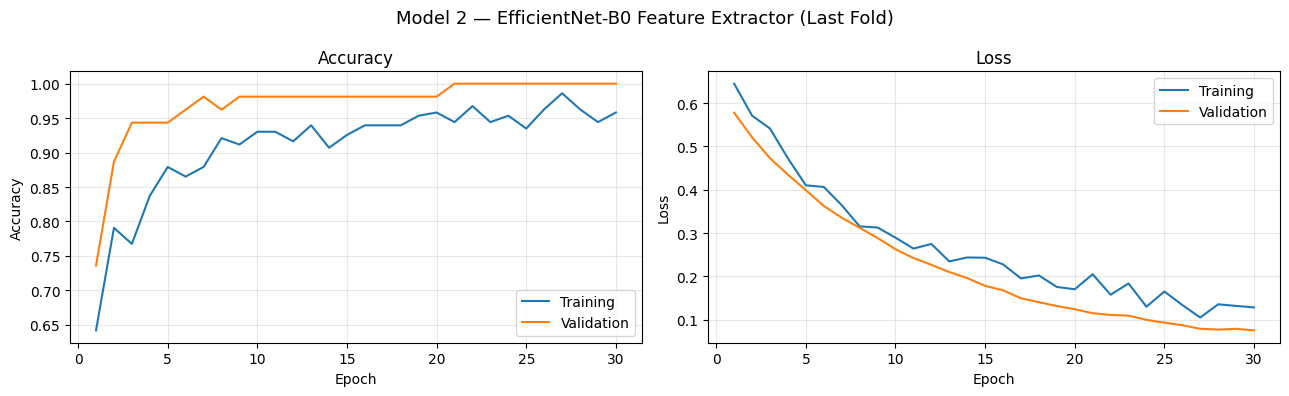

In [8]:
def plot_history(history, title):
    epochs = range(1, len(history["train_acc"]) + 1)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=13)

    ax1.plot(epochs, history["train_acc"], label="Training")
    ax1.plot(epochs, history["val_acc"],   label="Validation")
    ax1.set_title("Accuracy")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Accuracy")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    ax2.plot(epochs, history["train_loss"], label="Training")
    ax2.plot(epochs, history["val_loss"],   label="Validation")
    ax2.set_title("Loss")
    ax2.set_xlabel("Epoch")
    ax2.set_ylabel("Loss")
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_history(history, "Model 2 — EfficientNet-B0 Feature Extractor (Last Fold)")

## 10. Test Evaluation — Best Saved Model

We evaluate the **best checkpoint** (lowest val_loss across all folds) on the held-out test set.

The test set was never seen during training or model selection — it gives an unbiased
estimate of real-world performance.

> ⚠️ Only look at test results after you are done tuning. Repeatedly checking test
> performance and adjusting the model based on it turns the test set into a second
> validation set, which leads to overfitting to the test distribution.

In [9]:
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=0, pin_memory=False
)

test_loss, test_acc = evaluate(model, test_loader, criterion, DEVICE)
print(f"=== Test Results — Model 2 ===")
print(f"Accuracy : {test_acc:.3f}  ({test_acc * 100:.1f} %)")
print(f"Loss     : {test_loss:.3f}")

=== Test Results — Model 2 ===
Accuracy : 0.875  (87.5 %)
Loss     : 0.429


## 11. Prediction Grid

Visualizes model predictions on a balanced sample from the test set.
- **Green title** = correct prediction
- **Red title** = wrong prediction

We sample an equal number of images from each class to avoid the grid being dominated by the majority class.

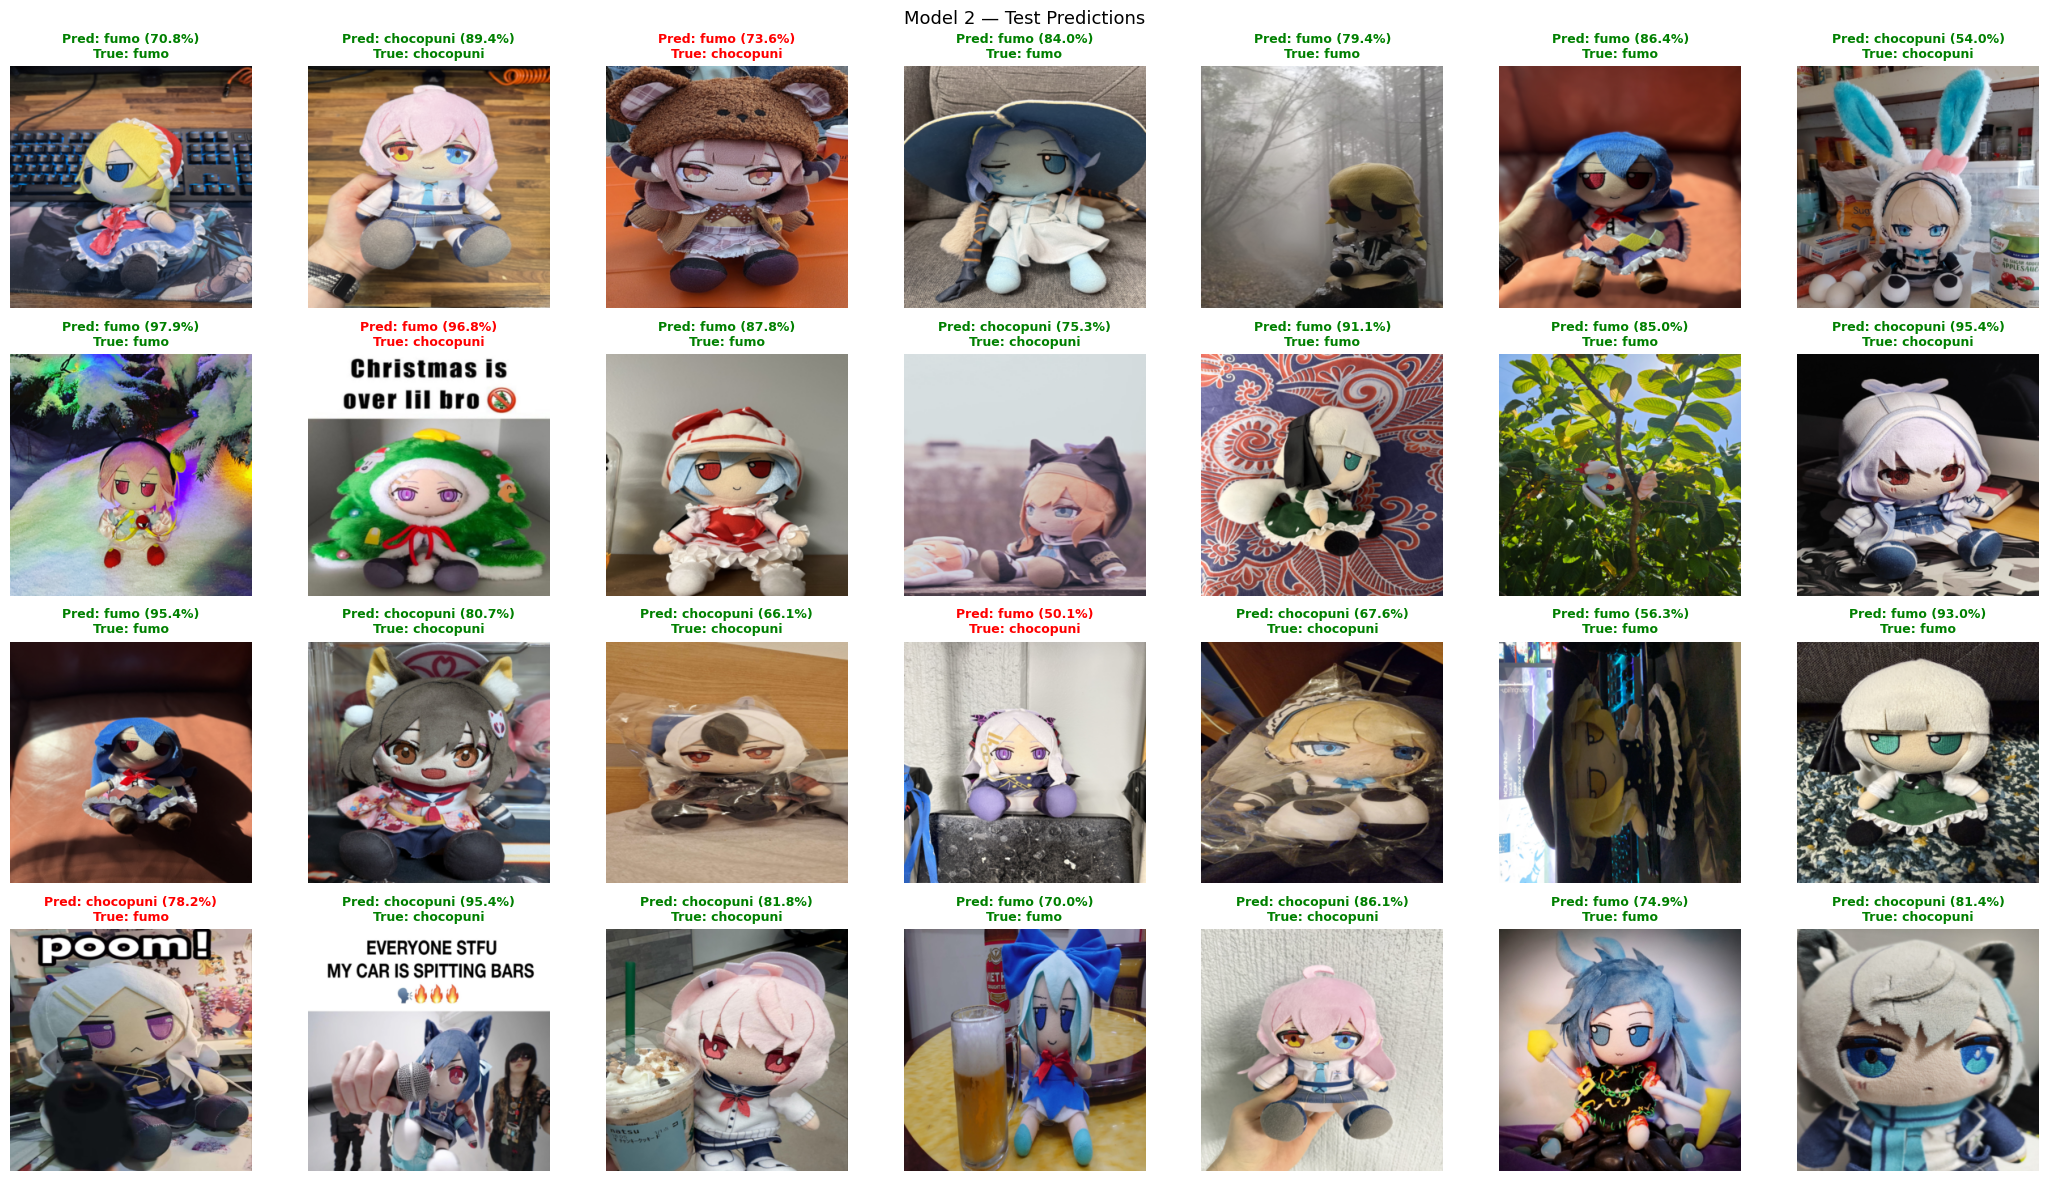

In [10]:
import math
import random

def denormalize(tensor):
    """Reverse ImageNet normalization for display."""
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std  = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return (tensor.cpu() * std + mean).clamp(0, 1)


# Collect n_per_class images from each class
n_per_class = 14
buckets = {i: [] for i in range(NUM_CLASSES)}
bucket_labels = {i: [] for i in range(NUM_CLASSES)}

for imgs, lbls in test_loader:
    for img, lbl in zip(imgs, lbls):
        cls = lbl.item()
        if len(buckets[cls]) < n_per_class:
            buckets[cls].append(img)
            bucket_labels[cls].append(lbl)
    if all(len(v) >= n_per_class for v in buckets.values()):
        break

# Build balanced, shuffled sample
selected = []
for cls in range(NUM_CLASSES):
    idx = random.sample(range(len(buckets[cls])), min(n_per_class, len(buckets[cls])))
    selected += [(buckets[cls][i], bucket_labels[cls][i]) for i in idx]

random.shuffle(selected)
images, labels = zip(*selected)
images = torch.stack(images)
n = len(images)

with torch.no_grad():
    outputs = model(images.to(DEVICE))
    probs   = torch.softmax(outputs, dim=1).cpu().numpy()

cols = 7
rows = math.ceil(n / cols)
plt.figure(figsize=(cols * 3, rows * 3))

for i in range(n):
    pred_idx   = np.argmax(probs[i])
    confidence = probs[i][pred_idx]
    true_idx   = labels[i].item()
    img_plot   = denormalize(images[i]).permute(1, 2, 0).numpy()

    plt.subplot(rows, cols, i + 1)
    plt.imshow(img_plot)
    color = "green" if pred_idx == true_idx else "red"
    plt.title(
        f"Pred: {CLASS_NAMES[pred_idx]} ({confidence*100:.1f}%)\n"
        f"True: {CLASS_NAMES[true_idx]}",
        color=color, fontsize=9, fontweight="bold"
    )
    plt.axis("off")

plt.suptitle("Model 2 — Test Predictions", fontsize=13)
plt.tight_layout()
plt.show()

## 12. Confusion Matrix

The confusion matrix

Bottom text



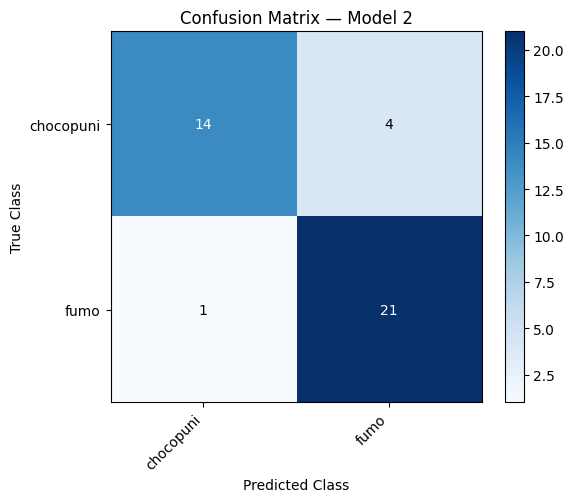

              precision    recall  f1-score   support

   chocopuni       0.93      0.78      0.85        18
        fumo       0.84      0.95      0.89        22

    accuracy                           0.88        40
   macro avg       0.89      0.87      0.87        40
weighted avg       0.88      0.88      0.87        40



In [11]:
all_preds, all_labels = [], []

model.eval()
for images, labels in test_loader:
    with torch.no_grad():
        outputs = model(images.to(DEVICE))
    preds = outputs.argmax(1).cpu().numpy()
    all_preds.extend(preds)
    all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation="nearest", cmap=plt.cm.Blues)
plt.colorbar(im, ax=ax)
ax.set_xticks(range(NUM_CLASSES))
ax.set_yticks(range(NUM_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted Class")
ax.set_ylabel("True Class")
ax.set_title("Confusion Matrix — Model 2")

thresh = cm.max() / 2
for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
    ax.text(j, i, cm[i, j], ha="center", va="center",
            color="white" if cm[i, j] > thresh else "black")
plt.tight_layout()
plt.show()

print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

## 13. Comparison with Model 1

Bar chart comparing test accuracy of Model 1 (custom CNN trained from scratch)
vs Model 2 (EfficientNet-B0 feature extractor).

Update `model1_acc` with your actual Model 1 test accuracy before running.

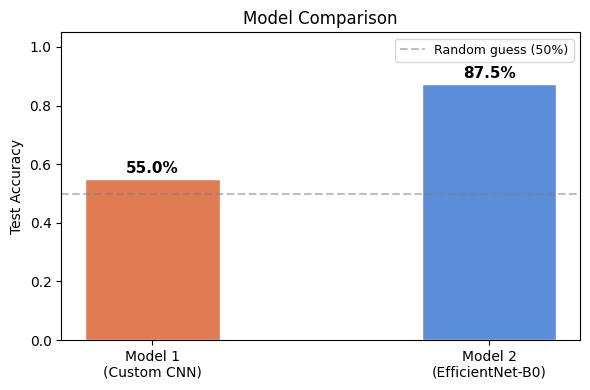

Improvement: +32.5 percentage points


In [ ]:
model1_acc = 0.61
model2_acc = test_acc

models_names = ["Model 1\n(Custom CNN)", "Model 2\n(EfficientNet-B0)"]
results      = [model1_acc, model2_acc]
colors       = ["#e07b54", "#5b8dd9"]

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(models_names, results, color=colors, width=0.4, edgecolor="white")
ax.set_ylim(0, 1.05)
ax.set_ylabel("Test Accuracy")
ax.set_title("Model Comparison")
ax.axhline(
    y=1/NUM_CLASSES, color="gray", linestyle="--", alpha=0.5,
    label=f"Random guess ({1/NUM_CLASSES:.0%})"
)
ax.legend(fontsize=9)
for bar, val in zip(bars, results):
    ax.text(
        bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
        f"{val:.1%}", ha="center", fontsize=11, fontweight="bold"
    )
plt.tight_layout()
plt.show()

improvement = (model2_acc - model1_acc) * 100
print(f"Improvement: {improvement:+.1f} percentage points")